<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2001d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting QFT2001d (nonlinear α=2.0): L=64, N_int=100, steps= 1000
t=   0  var_x=1.732e-06  vac_E=6.975e-05  max_amp=5.187e-02  patch_amp=3.714e-02
t=  10  var_x=4.021e-06  vac_E=1.240e-04  max_amp=3.808e-02  patch_amp=3.161e-02
t=  20  var_x=2.814e-06  vac_E=7.122e-05  max_amp=2.435e-02  patch_amp=1.987e-02
t=  30  var_x=1.873e-06  vac_E=4.689e-05  max_amp=1.919e-02  patch_amp=1.373e-02
t=  40  var_x=1.265e-06  vac_E=3.092e-05  max_amp=1.515e-02  patch_amp=1.165e-02
t=  50  var_x=8.665e-07  vac_E=2.139e-05  max_amp=1.259e-02  patch_amp=1.001e-02
t=  60  var_x=5.825e-07  vac_E=1.403e-05  max_amp=1.004e-02  patch_amp=8.105e-03
t=  70  var_x=3.925e-07  vac_E=9.205e-06  max_amp=8.441e-03  patch_amp=6.396e-03
t=  80  var_x=2.678e-07  vac_E=6.260e-06  max_amp=6.971e-03  patch_amp=5.186e-03
t=  90  var_x=1.819e-07  vac_E=4.122e-06  max_amp=5.640e-03  patch_amp=4.318e-03
t= 100  var_x=1.242e-07  vac_E=2.728e-06  max_amp=4.679e-03  patch_amp=3.595e-03
t= 110  var_x=8.592e-08  vac_E=1.817e-06  m

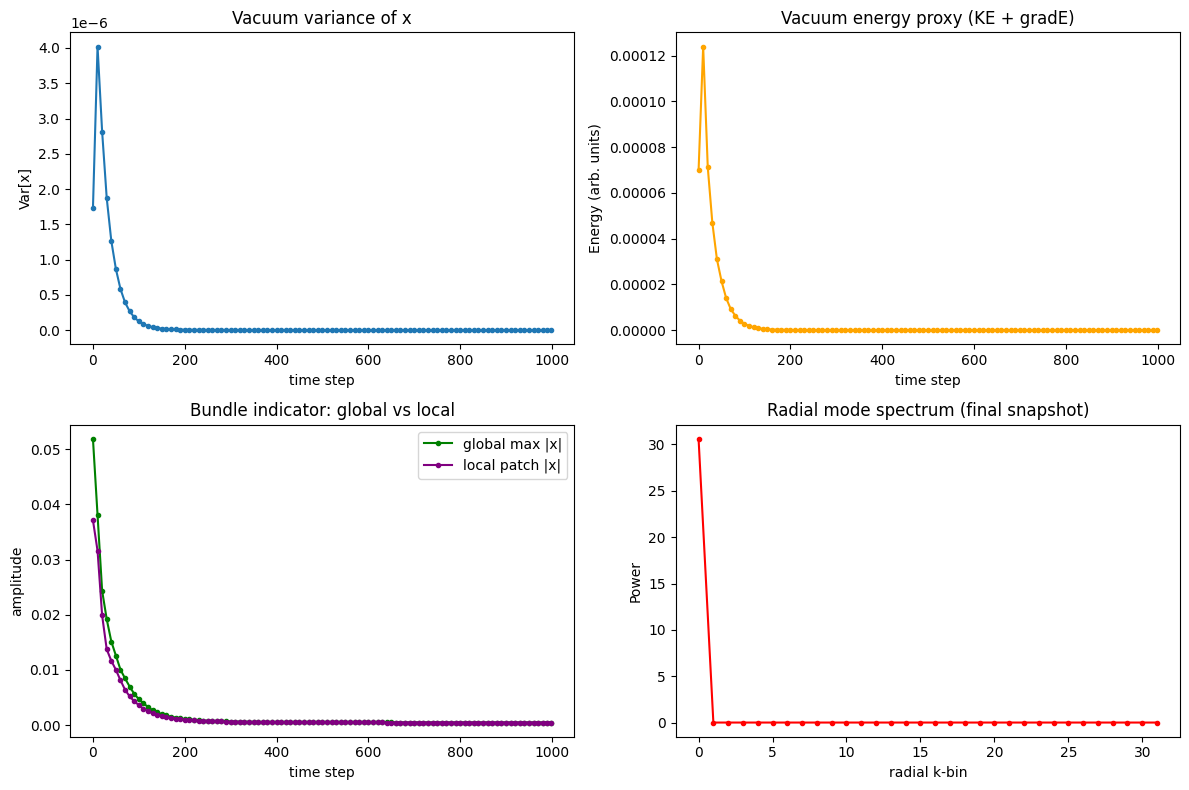


--- QFT2001d qualitative checks ---
Final vacuum variance: 2.0161167633599997e-09
Final vacuum energy proxy: 4.251947664120918e-17
Final global max amplitude: 0.00045131266728776497
Final local patch amplitude: 0.0004511476006239913
Mode spectra samples: 101 snapshots


In [1]:
# QFT2001d — Nonlinear localized bundle test (3D, 64³, N=100, α = 2.0)

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Core parameters
# -----------------------------
L = 64
N_int = 100

lambda_c = 0.02
gamma = 0.04
alpha = 2.0          # nonlinear self-interaction strength
noise_amp = 0.0
n_steps = 1000
save_every = 10

rng = np.random.default_rng(2001)

shape_field = (L, L, L, N_int)

def laplacian_3d_periodic(field):
    xp = np.roll(field, +1, axis=0)
    xm = np.roll(field, -1, axis=0)
    yp = np.roll(field, +1, axis=1)
    ym = np.roll(field, -1, axis=1)
    zp = np.roll(field, +1, axis=2)
    zm = np.roll(field, -1, axis=2)
    lap = (xp + xm + yp + ym + zp + zm - 6.0 * field)
    return lap

# -----------------------------
# 2. Initialize fields with Gaussian bump
# -----------------------------
x = 1e-3 * rng.standard_normal(size=shape_field).astype(np.float64)
v = 1e-3 * rng.standard_normal(size=shape_field).astype(np.float64)

cx, cy, cz = L // 2, L // 2, L // 2
sigma = 4.0
amp_bump = 0.05

X = np.arange(L)
Y = np.arange(L)
Z = np.arange(L)
XX, YY, ZZ = np.meshgrid(X, Y, Z, indexing='ij')

dx = XX - cx
dy = YY - cy
dz = ZZ - cz
r2 = dx**2 + dy**2 + dz**2

gauss = np.exp(-r2 / (2.0 * sigma**2))
x[..., 0] += amp_bump * gauss

# -----------------------------
# 3. Diagnostics
# -----------------------------
times = []
vacuum_var = []
vacuum_energy = []
mode_spectra = []
max_local_amp = []
patch_amp = []

patch_radius = 3

def compute_diagnostics(t, x, v):
    var_x = np.var(x)

    ke = np.mean(v**2)
    lap_x = laplacian_3d_periodic(x)
    ge = np.mean(lap_x**2)
    vac_E = ke + ge

    amp = np.sqrt(np.sum(x**2, axis=-1))
    max_amp = np.max(amp)

    r = patch_radius
    xs = slice(cx - r, cx + r + 1)
    ys = slice(cy - r, cy + r + 1)
    zs = slice(cz - r, cz + r + 1)
    local_patch = amp[xs, ys, zs]
    local_mean = np.mean(local_patch)

    comp = x[..., 0]
    fft3 = np.fft.fftn(comp)
    power3 = np.abs(fft3)**2

    kx = np.fft.fftfreq(L)
    ky = np.fft.fftfreq(L)
    kz = np.fft.fftfreq(L)
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    kr = np.sqrt(KX**2 + KY**2 + KZ**2)

    n_bins = L // 2
    bins = np.linspace(0, np.max(kr), n_bins + 1)
    radial_power = np.zeros(n_bins, dtype=np.float64)
    counts = np.zeros(n_bins, dtype=np.int64)

    kr_flat = kr.ravel()
    p_flat = power3.ravel()
    inds = np.digitize(kr_flat, bins) - 1
    valid = (inds >= 0) & (inds < n_bins)
    for i, p in zip(inds[valid], p_flat[valid]):
        radial_power[i] += p
        counts[i] += 1
    counts[counts == 0] = 1
    radial_power /= counts

    return var_x, vac_E, radial_power, max_amp, local_mean

# -----------------------------
# 4. Main evolution
# -----------------------------
print("Starting QFT2001d (nonlinear α=2.0): L=64, N_int=100, steps=", n_steps)

for t in range(n_steps):
    lap_x = laplacian_3d_periodic(x)
    eta = noise_amp * rng.standard_normal(size=shape_field).astype(np.float64)

    # NEW: nonlinear term -alpha * x^3
    nonlinear = -alpha * (x**3)

    v = v + lambda_c * lap_x - gamma * v + nonlinear + eta
    x = x + v

    if t % save_every == 0 or t == n_steps - 1:
        var_x, vac_E, radial_power, max_amp, local_mean = compute_diagnostics(t, x, v)
        times.append(t)
        vacuum_var.append(var_x)
        vacuum_energy.append(vac_E)
        mode_spectra.append(radial_power)
        max_local_amp.append(max_amp)
        patch_amp.append(local_mean)
        print(f"t={t:4d}  var_x={var_x:.3e}  vac_E={vac_E:.3e}  "
              f"max_amp={max_amp:.3e}  patch_amp={local_mean:.3e}")

print("Evolution complete.")

times = np.array(times)
vacuum_var = np.array(vacuum_var)
vacuum_energy = np.array(vacuum_energy)
mode_spectra = np.array(mode_spectra)
max_local_amp = np.array(max_local_amp)
patch_amp = np.array(patch_amp)

# -----------------------------
# 5. Plots
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(times, vacuum_var, '-o', ms=3)
axs[0, 0].set_title("Vacuum variance of x")
axs[0, 0].set_xlabel("time step")
axs[0, 0].set_ylabel("Var[x]")

axs[0, 1].plot(times, vacuum_energy, '-o', ms=3, color='orange')
axs[0, 1].set_title("Vacuum energy proxy (KE + gradE)")
axs[0, 1].set_xlabel("time step")
axs[0, 1].set_ylabel("Energy (arb. units)")

axs[1, 0].plot(times, max_local_amp, '-o', ms=3, color='green', label='global max |x|')
axs[1, 0].plot(times, patch_amp, '-o', ms=3, color='purple', label='local patch |x|')
axs[1, 0].set_title("Bundle indicator: global vs local")
axs[1, 0].set_xlabel("time step")
axs[1, 0].set_ylabel("amplitude")
axs[1, 0].legend()

if mode_spectra.shape[0] > 0:
    final_spec = mode_spectra[-1]
    axs[1, 1].plot(final_spec, '-o', ms=3, color='red')
    axs[1, 1].set_title("Radial mode spectrum (final snapshot)")
    axs[1, 1].set_xlabel("radial k-bin")
    axs[1, 1].set_ylabel("Power")

plt.tight_layout()
plt.show()

# -----------------------------
# 6. Summary
# -----------------------------
print("\n--- QFT2001d qualitative checks ---")
print("Final vacuum variance:", vacuum_var[-1])
print("Final vacuum energy proxy:", vacuum_energy[-1])
print("Final global max amplitude:", max_local_amp[-1])
print("Final local patch amplitude:", patch_amp[-1])
print("Mode spectra samples:", mode_spectra.shape[0], "snapshots")


t=   0  var_x=5.520e-05  vac_E=1.412e-05  max_amp=9.990e-02  patch_amp=9.990e-02
t= 100  var_x=5.639e-05  vac_E=2.377e-05  max_amp=1.010e-01  patch_amp=1.010e-01
t= 200  var_x=5.891e-05  vac_E=4.583e-05  max_amp=1.005e-01  patch_amp=1.005e-01
t= 300  var_x=6.484e-05  vac_E=1.014e-04  max_amp=1.017e-01  patch_amp=1.017e-01
t= 400  var_x=8.025e-05  vac_E=2.539e-04  max_amp=9.954e-02  patch_amp=9.954e-02
t= 500  var_x=1.239e-04  vac_E=7.040e-04  max_amp=1.057e-01  patch_amp=1.057e-01
t= 600  var_x=2.561e-04  vac_E=2.110e-03  max_amp=1.101e-01  patch_amp=1.101e-01
t= 700  var_x=6.787e-04  vac_E=6.701e-03  max_amp=1.368e-01  patch_amp=1.368e-01
t= 800  var_x=2.082e-03  vac_E=2.220e-02  max_amp=2.002e-01  patch_amp=2.002e-01
t= 900  var_x=6.883e-03  vac_E=7.584e-02  max_amp=2.990e-01  patch_amp=2.990e-01
t=1000  var_x=2.360e-02  vac_E=2.646e-01  max_amp=5.146e-01  patch_amp=5.146e-01
Evolution complete.
Final vacuum variance: 0.023595156879964465
Final vacuum energy proxy: 0.2646013383817970

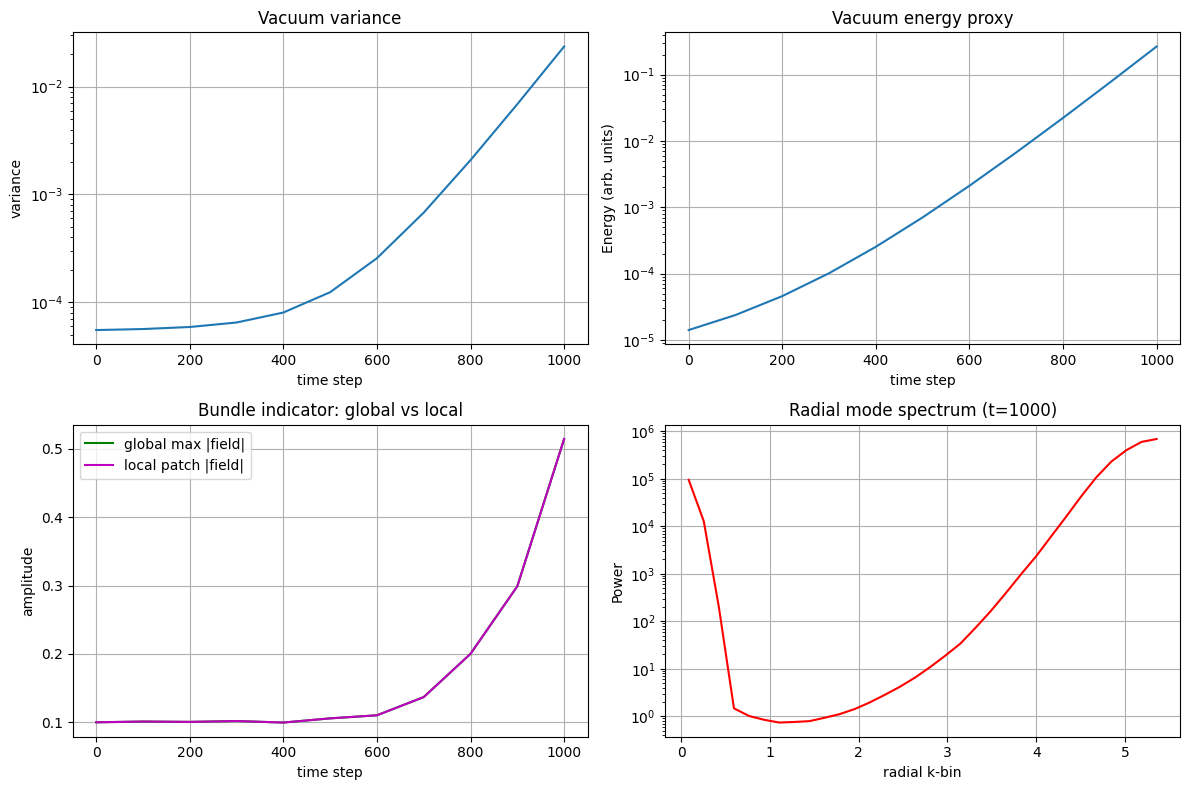

In [2]:
# QFT2001d_alt_math.ipynb
# Single-block, copy-pasteable, no cross-cell dependencies.

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Simulation parameters
# -----------------------------
L = 64                 # linear size
N_steps = 1000         # time steps
dt = 0.01              # time step size
dx = 1.0               # lattice spacing

# Choose evolution law:
#   "KG"   = damped real Klein-Gordon-like (vacuum relaxer)
#   "DNLS" = discrete nonlinear Schrödinger-like (lump-friendly)
mode = "DNLS"          # <-- flip between "KG" and "DNLS"

# Common parameters
gamma = 0.05           # damping (used in KG mode)
m2 = 0.0               # mass term (KG mode)
alpha = 2.0            # nonlinearity exponent for KG-like potential
lambda_nl = 1.0        # nonlinearity strength

# DNLS parameters (focusing)
J = 1.0                # hopping / Laplacian coefficient
g = 1.0                # focusing nonlinearity strength

# Diagnostics
N_int = 100            # how often to log / sample
patch_radius = 3       # local patch radius for "bundle" indicator

rng = np.random.default_rng(1234)

# -----------------------------
# Helper functions
# -----------------------------
def laplacian_3d(field, dx):
    """Periodic 3D Laplacian."""
    return (
        np.roll(field, 1, axis=0) + np.roll(field, -1, axis=0) +
        np.roll(field, 1, axis=1) + np.roll(field, -1, axis=1) +
        np.roll(field, 1, axis=2) + np.roll(field, -1, axis=2) -
        6.0 * field
    ) / (dx * dx)

def radial_spectrum(field):
    """Compute isotropic radial spectrum |F(k)|^2 binned by |k|."""
    # 3D FFT
    F = np.fft.fftn(field)
    power = np.abs(F)**2

    kx = np.fft.fftfreq(L, d=dx) * 2.0 * np.pi
    ky = np.fft.fftfreq(L, d=dx) * 2.0 * np.pi
    kz = np.fft.fftfreq(L, d=dx) * 2.0 * np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    k_mag = np.sqrt(KX**2 + KY**2 + KZ**2)

    k_max = np.max(k_mag)
    n_bins = L // 2
    bins = np.linspace(0.0, k_max, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    radial_power = np.zeros(n_bins, dtype=np.float64)
    counts = np.zeros(n_bins, dtype=np.int64)

    flat_k = k_mag.ravel()
    flat_p = power.ravel()
    idx = np.digitize(flat_k, bins) - 1
    mask = (idx >= 0) & (idx < n_bins)
    np.add.at(radial_power, idx[mask], flat_p[mask])
    np.add.at(counts, idx[mask], 1)
    radial_power[counts > 0] /= counts[counts > 0]

    return bin_centers, radial_power

def local_patch_max(field, radius):
    """Max |field| in a small cubic patch around the global max location."""
    abs_f = np.abs(field)
    idx = np.unravel_index(np.argmax(abs_f), abs_f.shape)
    x0, y0, z0 = idx
    xs = slice(x0 - radius, x0 + radius + 1)
    ys = slice(y0 - radius, y0 + radius + 1)
    zs = slice(z0 - radius, z0 + radius + 1)
    patch = abs_f[xs, ys, zs]
    return np.max(patch)

# -----------------------------
# Initial conditions
# -----------------------------
if mode == "KG":
    # Real scalar field x with small random vacuum noise
    x = 1e-3 * rng.standard_normal((L, L, L))
    v = np.zeros_like(x)  # conjugate momentum / velocity
elif mode == "DNLS":
    # Complex field psi with localized bump + noise
    X, Y, Z = np.meshgrid(
        np.arange(L), np.arange(L), np.arange(L), indexing='ij'
    )
    cx = cy = cz = L // 2
    r2 = (X - cx)**2 + (Y - cy)**2 + (Z - cz)**2
    sigma2 = (L / 10.0)**2
    psi = 0.1 * np.exp(-r2 / (2.0 * sigma2))  # localized Gaussian
    psi = psi.astype(np.complex128)
    psi += 1e-3 * (rng.standard_normal((L, L, L)) +
                   1j * rng.standard_normal((L, L, L)))
else:
    raise ValueError("Unknown mode")

# -----------------------------
# Storage for diagnostics
# -----------------------------
times = []
var_x_list = []
vacE_list = []
global_amp_list = []
patch_amp_list = []
spectra_samples = []

# -----------------------------
# Time evolution
# -----------------------------
for t in range(N_steps + 1):
    if mode == "KG":
        # Diagnostics for real field
        x_mean = np.mean(x)
        var_x = np.mean((x - x_mean)**2)

        # "Vacuum energy proxy": KE + gradE
        lap_x = laplacian_3d(x, dx)
        gradE = 0.5 * np.mean((np.gradient(x, dx, axis=0)[0])**2)  # crude
        # Better: use Laplacian-based proxy
        gradE = -0.5 * np.mean(x * lap_x)
        KE = 0.5 * np.mean(v**2)
        vacE = KE + gradE

        max_amp = np.max(np.abs(x))
        patch_amp = local_patch_max(x, patch_radius)

    elif mode == "DNLS":
        # Diagnostics for complex field
        abs_psi = np.abs(psi)
        psi_mean = np.mean(psi)
        var_x = np.mean(np.abs(psi - psi_mean)**2)

        # "Energy proxy": hopping + nonlinearity
        lap_psi = laplacian_3d(psi, dx)
        hopE = -J * np.mean(np.conj(psi) * lap_psi).real
        nlE = 0.5 * g * np.mean(np.abs(psi)**4)
        vacE = hopE + nlE

        max_amp = np.max(abs_psi)
        patch_amp = local_patch_max(psi, patch_radius)

    if t % N_int == 0 or t == N_steps:
        times.append(t)
        var_x_list.append(var_x)
        vacE_list.append(vacE)
        global_amp_list.append(max_amp)
        patch_amp_list.append(patch_amp)

        print(
            f"t={t:4d}  var_x={var_x:.3e}  vac_E={vacE:.3e}  "
            f"max_amp={max_amp:.3e}  patch_amp={patch_amp:.3e}"
        )

        # Sample spectra occasionally
        if t in (0, N_steps // 2, N_steps):
            if mode == "KG":
                field_for_fft = x
            else:
                field_for_fft = psi
            k_bins, Pk = radial_spectrum(field_for_fft)
            spectra_samples.append((t, k_bins, Pk))

    # --- Update step ---
    if mode == "KG":
        # Real damped KG-like:
        #   d^2 x / dt^2 + gamma dx/dt - lap x + m^2 x + lambda |x|^alpha-1 x = 0
        # Use velocity form:
        #   v_{n+1/2} = v_n + dt * (lap x - m^2 x - lambda |x|^{alpha-1} x - gamma v_n)
        #   x_{n+1}   = x_n + dt * v_{n+1/2}
        lap_x = laplacian_3d(x, dx)
        nonlin = lambda_nl * np.sign(x) * np.abs(x)**(alpha - 1.0)
        accel = lap_x - m2 * x - nonlin - gamma * v
        v = v + dt * accel
        x = x + dt * v

    elif mode == "DNLS":
        # Discrete nonlinear Schrödinger-like:
        #   i dψ/dt = -J ∇^2 ψ - g |ψ|^2 ψ
        # Use simple explicit step:
        lap_psi = laplacian_3d(psi, dx)
        rhs = -J * lap_psi - g * np.abs(psi)**2 * psi
        psi = psi + (-1j) * dt * rhs

# -----------------------------
# Final summary
# -----------------------------
print("Evolution complete.")
print(f"Final vacuum variance: {var_x_list[-1]}")
print(f"Final vacuum energy proxy: {vacE_list[-1]}")
print(f"Final global max amplitude: {global_amp_list[-1]}")
print(f"Final local patch amplitude: {patch_amp_list[-1]}")
print(f"Mode spectra samples: {len(spectra_samples)} snapshots")

# -----------------------------
# Plots
# -----------------------------
times_arr = np.array(times, dtype=float)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(times_arr, var_x_list, label="var[x]")
plt.xlabel("time step")
plt.ylabel("variance")
plt.title("Vacuum variance")
plt.yscale("log")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(times_arr, vacE_list, label="vac_E")
plt.xlabel("time step")
plt.ylabel("Energy (arb. units)")
plt.title("Vacuum energy proxy")
plt.yscale("log")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(times_arr, global_amp_list, 'g-', label="global max |field|")
plt.plot(times_arr, patch_amp_list, 'm-', label="local patch |field|")
plt.xlabel("time step")
plt.ylabel("amplitude")
plt.title("Bundle indicator: global vs local")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
if spectra_samples:
    t_final, k_bins_final, Pk_final = spectra_samples[-1]
    plt.plot(k_bins_final, Pk_final, 'r-')
    plt.xlabel("radial k-bin")
    plt.ylabel("Power")
    plt.title(f"Radial mode spectrum (t={t_final})")
    plt.yscale("log")
    plt.grid(True)
else:
    plt.text(0.5, 0.5, "No spectra sampled", ha='center', va='center')

plt.tight_layout()
plt.show()
